## Notebook Analysis and evaluation metrics. 

Following the resulting models trained up from 
1. Wikitext
2. BookCorpus
3. BookCorpus with data-centric optimisation,

we have decided to measure our models based on the following metrics:

1. Prompts of varying sizes to understand how good the model is comfortable in generating responses(maximum upto 120 tokens per prompt )

2. The varying size brackets we have considered are as follows:
   1. Short prompts of size (around 5-6)
   2. Medium sized prompts of size (around 10-11)
   3. Longer sized prompts of size (around 15 tokens in length)

The reason to end our evaluation metrics after prompts of size 15 (even though, these are shorter in general)

Modern Factual Data and context is absent or missing to a larger extent in our training datasets. 

This drove our intutition and thoughts towards prompts of proper Enlgish literature well with the motive that bad/poorly structured prompts yield poor respones. We instead focused on multiple activities and actions that tests how good the model yields responses.

# Imports

In [35]:
!pip install nltk
!pip install sentence_transformers
!pip install matplotlib

  Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (117 kB)
  Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl.metadata (5.1 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.8/8.8 MB 6.4 MB/s  0:00:01 eta 0:00:01m
Using cached contourpy-1.3.2-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (325 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
Using cached fonttools-4.62.1-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.whl (4.9 MB)
Using cached kiwisolver-1.5.0-cp310-cp310-manylinux_2_12_x86_64.manylinux2010_x86_64.whl (1.6 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotl

In [36]:
import math                                                   # for perplexity
import re                                                     # for sentence splitting
import numpy as np
import torch                                                  
import torch.nn as nn                                         # neural-network modules
import torch.nn.functional as F                              # softmax, cross_entropy …
from nltk.util import ngrams                                 # repetition + distinct-n
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer         # semantic drift
from transformers import GPT2LMHeadModel, GPT2TokenizerFast  # reference PPL model

## Configuration setup 

In [3]:

VOCAB_SIZE  = 50257
N_EMBD      = 512
N_HEAD      = 8
N_LAYER     = 8
BLOCK_SIZE  = 256
DROPOUT     = 0.1   

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Ti


## File paths that point to the saved models

In [4]:
WIKITEXT_model = "../Models/Wikitext.pt"
BookCorpusv1_model = "../Models/BookCorpusv1.pt"
BookCorpusv2_model = "../Models/BookCorpusv2.pt"

## Model's architecture

In [5]:
class Head(nn.Module):
    def __init__(self, n_embd, head_size, block_size, dropout):
        super().__init__()
        self.key   = nn.Linear(n_embd, head_size, bias=False)
        self.query = nn.Linear(n_embd, head_size, bias=False)
        self.value = nn.Linear(n_embd, head_size, bias=False)
        self.register_buffer(
            "tril",
            torch.tril(torch.ones(block_size, block_size)).bool()
        )
        self.attn_dropout = nn.Dropout(dropout)

    def forward(self, x):
        B, T, C = x.shape
        k = self.key(x)
        q = self.query(x)
        wei = q @ k.transpose(-2, -1) * (k.shape[-1] ** -0.5)
        wei = wei.masked_fill(~self.tril[:T, :T], float("-inf"))
        wei = F.softmax(wei, dim=-1)
        wei = self.attn_dropout(wei)
        v = self.value(x)
        return wei @ v

In [6]:
class MultiHeadAttention(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        head_size = n_embd // n_head
        self.heads = nn.ModuleList([
            Head(n_embd, head_size, block_size, dropout) for _ in range(n_head)
        ])
        self.proj          = nn.Linear(n_embd, n_embd)
        self.resid_dropout = nn.Dropout(dropout)

    def forward(self, x):
        out = torch.cat([h(x) for h in self.heads], dim=-1)
        return self.resid_dropout(self.proj(out))

In [7]:
class FeedForward(nn.Module):
    def __init__(self, n_embd, dropout):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(n_embd, 4 * n_embd),
            nn.GELU(),
            nn.Linear(4 * n_embd, n_embd),
            nn.Dropout(dropout),
        )

    def forward(self, x):
        return self.net(x)

In [8]:
class Block(nn.Module):
    def __init__(self, n_embd, n_head, block_size, dropout):
        super().__init__()
        self.ln1 = nn.LayerNorm(n_embd)
        self.sa  = MultiHeadAttention(n_embd, n_head, block_size, dropout)
        self.ln2 = nn.LayerNorm(n_embd)
        self.ff  = FeedForward(n_embd, dropout)

    def forward(self, x):
        x = x + self.sa(self.ln1(x))
        x = x + self.ff(self.ln2(x))
        return x

In [9]:
class GPT(nn.Module):
    def __init__(self, vocab_size, n_embd, n_head, n_layer, block_size, dropout, device):
        super().__init__()
        self.device     = device
        self.block_size = block_size

        self.token_embedding_table    = nn.Embedding(vocab_size, n_embd)
        self.position_embedding_table = nn.Embedding(block_size, n_embd)

        self.blocks  = nn.Sequential(*[
            Block(n_embd, n_head, block_size, dropout) for _ in range(n_layer)
        ])
        self.ln_f    = nn.LayerNorm(n_embd)
        self.lm_head = nn.Linear(n_embd, vocab_size, bias=False)
        # Weight tying: share embedding and output weights
        self.lm_head.weight = self.token_embedding_table.weight

    def forward(self, idx, targets=None):
        B, T = idx.shape
        tok    = self.token_embedding_table(idx)
        pos    = self.position_embedding_table(torch.arange(T, device=self.device))
        x      = self.blocks(tok + pos)
        x      = self.ln_f(x)
        logits = self.lm_head(x)

        loss = None
        if targets is not None:
            loss = F.cross_entropy(logits.view(B * T, -1), targets.view(B * T))
        return logits, loss

    @torch.no_grad()
    def generate(self, idx, max_new_tokens=100, temperature=0.8, top_k=40, top_p=0.9,
                 repetition_penalty=1.15, stop_on_eos=True, eos_token_id=50256):
       
        for _ in range(max_new_tokens):
            idx_cond = idx[:, -self.block_size:]
            logits, _ = self(idx_cond)
            logits = logits[:, -1, :]           # last-token logits: (B, vocab)

            # Repetition penalty
            if repetition_penalty != 1.0:
                for token_id in set(idx[0].tolist()):
                    if logits[0, token_id] > 0:
                        logits[0, token_id] /= repetition_penalty
                    else:
                        logits[0, token_id] *= repetition_penalty

            # Temperature scaling
            logits = logits / temperature

            # Top-k filtering
            if top_k:
                v, _ = torch.topk(logits, top_k)
                logits[logits < v[:, -1, None]] = float("-inf")

            probs = F.softmax(logits, dim=-1)

            # Top-p (nucleus) filtering
            if top_p < 1.0:
                sorted_probs, sorted_idx = torch.sort(probs, descending=True)
                cumulative = torch.cumsum(sorted_probs, dim=-1)
                mask = cumulative - sorted_probs > top_p
                sorted_probs[mask] = 0.0
                probs = torch.zeros_like(probs).scatter_(1, sorted_idx, sorted_probs)
                probs = probs / probs.sum(dim=-1, keepdim=True)

            idx_next = torch.multinomial(probs, num_samples=1)
            idx      = torch.cat((idx, idx_next), dim=1)

            if stop_on_eos and idx_next.item() == eos_token_id:
                break

        return idx

## Loading the models

In [10]:
def _load_checkpoint(path, device):
    """Load a GPT checkpoint (raw state_dict or wrapped dict) into a fresh model."""
    m = GPT(VOCAB_SIZE, N_EMBD, N_HEAD, N_LAYER, BLOCK_SIZE, DROPOUT, device).to(device)
    raw = torch.load(path, map_location=device, weights_only=False)
    if isinstance(raw, dict) and "model_state_dict" in raw:
        if "config" in raw:
            print(f"  config: {raw['config']}")
        raw = raw["model_state_dict"]
    cleaned = {k.replace("_orig_mod.", ""): v for k, v in raw.items()}
    m.load_state_dict(cleaned, strict=True)
    m.eval()
    n_params = sum(p.numel() for p in m.parameters())
    print(f"  {n_params:,} parameters loaded.")
    return m

print("Loading Wikitext model …")
wikitext_model = _load_checkpoint(WIKITEXT_model, DEVICE)

print("Loading BookCorpus v1 model …")
bookcorpus_v1_model = _load_checkpoint(BookCorpusv1_model, DEVICE)

print("Loading BookCorpus v2 model …")
bookcorpus_v2_model = _load_checkpoint(BookCorpusv2_model, DEVICE)

MODELS = {
    "Wikitext"       : wikitext_model,
    "BookCorpus-v1"  : bookcorpus_v1_model,
    "BookCorpus-v2"  : bookcorpus_v2_model,
}
print("\nAll models loaded.")

Loading Wikitext model …
  config: {'batch_size': 16, 'block_size': 256, 'max_iters': 25000, 'learning_rate': 0.0002, 'n_embd': 512, 'n_head': 8, 'n_layer': 8, 'grad_accum': 4, 'dropout': 0.1, 'eval_interval': 500, 'eval_iters': 100, 'warmup_steps': 1000, 'patience': 10, 'device': 'cuda'}
  51,070,464 parameters loaded.
Loading BookCorpus v1 model …
  config: {'batch_size': 16, 'block_size': 256, 'max_iters': 28000, 'learning_rate': 6.1e-05, 'n_embd': 512, 'n_head': 8, 'n_layer': 8, 'grad_accum': 8, 'dropout': 0.1, 'eval_interval': 500, 'eval_iters': 100, 'warmup_steps': 100, 'patience': 10, 'max_grad_norm': 1.0, 'device': 'cuda'}
  51,070,464 parameters loaded.
Loading BookCorpus v2 model …
  config: {'batch_size': 16, 'block_size': 256, 'max_iters': 50000, 'learning_rate': 0.0001, 'n_embd': 512, 'n_head': 8, 'n_layer': 8, 'grad_accum': 8, 'dropout': 0.1, 'eval_interval': 500, 'eval_iters': 100, 'warmup_steps': 1000, 'patience': 10, 'max_grad_norm': 1.0, 'device': 'cuda'}
  51,070,464

## Tokeniser and reference tokeniser.

We opted for a pretrained GPT2LMModel as our reference model to score perplexity

In [11]:
tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
print(f"Tokenizer ready. Vocab size: {tokenizer.vocab_size}")

Tokenizer ready. Vocab size: 50257


In [12]:
_ref_tokenizer = GPT2TokenizerFast.from_pretrained("gpt2")
_ref_model     = GPT2LMHeadModel.from_pretrained("gpt2").eval()
print("Reference GPT-2 loaded.")

Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 148/148 [00:00<00:00, 20693.97it/s]


Reference GPT-2 loaded.


# Prompt generator

In [13]:
def generate_text(model, prompt, max_new_tokens=120, temperature=0.8,
                  top_k=40, top_p=0.9, repetition_penalty=1.15, seed=None):
    """
    Generate text from `prompt` using the given model.

    Args:
        model              : one of the GPT instances in MODELS
        prompt             : string to continue
        max_new_tokens     : tokens to generate (default 120, per evaluation spec)
        temperature        : 0.7–0.9 (lower = focused, higher = creative)
        top_k              : top-K vocabulary filter
        top_p              : nucleus probability threshold
        repetition_penalty : 1.1–1.3 (1.0 = disabled)
        seed               : int for reproducible output, or None
    """
    if seed is not None:
        torch.manual_seed(seed)
    input_ids = tokenizer.encode(prompt, return_tensors="pt").to(DEVICE)
    output_ids = model.generate(
        input_ids,
        max_new_tokens=max_new_tokens,
        temperature=temperature,
        top_k=top_k,
        top_p=top_p,
        repetition_penalty=repetition_penalty,
    )
    return tokenizer.decode(output_ids[0].tolist(), skip_special_tokens=True)

# Evaluation metrics

Given our goal to analyse how long seqeunces of generated text are coherent amongst themselves, the evaluation metrics that were chosen are : 

1. Repetition Scor

AR models trained on small or homogenous text corpus fall into repetition loops - produces phases like "he was good, he was good, he was good". 
This is one of the most visible failure modes at inference time and directly impacts readability. 

Tracking it gives a measure on how well the penalty parameter works, and how they capture diverse contexts. 

2. Distinct-N

While repetition loops can be fixed, the model might still be producing bad, low-entropy text with a bunch of common words. Distinct-N measures exactly this. 
This penalises generic, safe responses.

3. Semantic Driff:
    Coherence over long text sequences is difficult for small language models to generate.
    A model might generate fluent sentence-by-sentence outputs, but they might be drifting completely off-topic by either 5 or 6th sentence onwards.

4. Perplexity

    Standard proxy for fluency.
    Signals whether the text is grammatical and idomatic - covers the grammatical aspects of generated sequence. 

In [14]:
def repetition_score(text, n=2):
    """Fraction of duplicate bigrams. Higher = more repetitive."""
    tokens = text.split()
    if len(tokens) < n:
        return 0.0
    grams = list(ngrams(tokens, n))
    return 1 - len(set(grams)) / len(grams)

In [15]:
def distinct_n(text, n=1):
    """Ratio of unique n-grams to total. Higher = more diverse vocabulary."""
    tokens = text.split()
    if len(tokens) < n:
        return 0.0
    grams = list(ngrams(tokens, n))
    return len(set(grams)) / len(grams)


In [19]:
_sbert = SentenceTransformer("all-MiniLM-L6-v2")

def semantic_drift(text, segment_length=30):
    tokens = text.split()
    if len(tokens) < 2 * segment_length:
        return 1.0
    e1 = _sbert.encode(" ".join(tokens[:segment_length]),  convert_to_tensor=True)
    e2 = _sbert.encode(" ".join(tokens[-segment_length:]), convert_to_tensor=True)
    return F.cosine_similarity(e1, e2, dim=0).item()


Loading weights: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 103/103 [00:00<00:00, 27581.77it/s]
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [20]:
def perplexity(text):

    enc = _ref_tokenizer(text, return_tensors="pt")
    with torch.no_grad():
        loss = _ref_model(enc.input_ids, labels=enc.input_ids).loss
    return math.exp(loss.item())


In [18]:
def evaluate(text):
    return {
        "repetition_score" : round(repetition_score(text), 4),
        "distinct_1"       : round(distinct_n(text, 1),    4),
        "distinct_2"       : round(distinct_n(text, 2),    4),
        "semantic_drift"   : round(semantic_drift(text),   4),
        "perplexity"       : round(perplexity(text),       2),
    }

In [22]:
def compute_stats(results):
    """
    Given a list of per-prompt result dicts (as produced by the eval loops below),
    return mean / std / min / max for every numeric metric.
    """
    metric_keys = ["repetition_score", "semantic_drift", "distinct_1", "distinct_2", "perplexity"]
    stats = {}
    for k in metric_keys:
        vals = [r[k] for r in results if k in r]
        if vals:
            stats[f"{k}_mean"] = round(np.mean(vals), 4)
            stats[f"{k}_std"]  = round(np.std(vals),  4)
            stats[f"{k}_min"]  = round(np.min(vals),  4)
            stats[f"{k}_max"]  = round(np.max(vals),  4)
    return stats

## Batch inferncing and evaluation 

As mentioned earlier, we have decided to evaluate generated results for prompts of varying lengths : 5, 10 and 15.

Each batch consists of equal number of 30 prompts. 

In [23]:
def run_prompts(prompts, label, max_new_tokens=120,
                temperature=0.8, top_k=40, top_p=0.9,
                repetition_penalty=1.15, seed=42):

    results = {name: [] for name in MODELS}
    sep = "=" * 72

    print(f"\n{sep}")
    print(f"  {label}")
    print(sep)

    for prompt in prompts:
        print(f"\n  PROMPT: {prompt!r}")
        print("-" * 72)
        for model_name, model in MODELS.items():
            output = generate_text(
                model, prompt,
                max_new_tokens=max_new_tokens,
                temperature=temperature,
                top_k=top_k,
                top_p=top_p,
                repetition_penalty=repetition_penalty,
                seed=seed,
            )
            score = evaluate(output)
            results[model_name].append({"prompt": prompt, "output": output, **score})
            print(f"  [{model_name}]")
            print(f"  {output}")
            print(f"  Scores: {score}\n")

    return results

## Batches chosen for inference. 

### 1. Batches of prompts for size 5.

Trivial, prompts of lengths spanning around 5-7 tokens. 

Choice of prompts included various actions such as :
1. idiomatic expressions for weather.
2. actions like looking, holdinng, stepping forward, etc..
3. Most of the subjects belong to male and female gender category highlighting the lack of modern english texual usage for generation of data.


Similarly the batches for prompts of size 10 and 15 follow similar  actions with increasing context on the prompt being presented to the model. 

In [24]:
PROMPT_5 = [
    "The night was cold and silent",
    "He looked at the sky and",
    "The road stretched far ahead",
    "She held the letter and",
    "A shadow moved behind him",
    "The room was quiet and still",
    "He stepped forward and paused",
    "The wind whispered through the trees",
    "She turned around and saw",
    "The door creaked open slowly",
    "He stood alone in silence",
    "The light flickered in the distance",
    "She walked into the empty room",
    "The sound echoed in the hall",
    "He felt something was wrong",
    "The path disappeared into darkness",
    "She reached out her hand slowly",
    "The air felt heavy and still",
    "He glanced back over his shoulder",
    "The window rattled in the wind",
    "She waited quietly for a moment",
    "The figure stood in the shadows",
    "He listened but heard nothing",
    "The silence grew louder around them",
    "She closed her eyes and waited",
    "The ground trembled beneath his feet",
    "He noticed something strange nearby",
    "The darkness closed in slowly",
    "She took a step forward carefully",
    "The horizon faded into the mist",
]

In [25]:
PROMPT_10 = [
    "The wind blew softly through the empty streets at night",
    "He turned around and saw something unexpected behind him there",
    "The house at the corner seemed strangely quiet that evening",
    "She stepped forward and felt something was wrong inside",
    "The river flowed quietly under the old bridge at dusk",
    "He walked slowly down the road without looking back again",
    "The room was filled with silence as she entered quietly",
    "She looked around and noticed everything had changed suddenly",
    "The lights flickered softly as the night grew darker outside",
    "He stood near the door wondering if he should go inside",
    "The forest seemed alive as shadows moved between the trees",
    "She held her breath as the sound grew louder behind her",
    "The sky turned grey as the storm approached from afar",
    "He opened the door and stepped into the unfamiliar place",
    "The silence around them felt heavier with each passing moment",
    "She turned away slowly as the voice called out her name",
    "The narrow path led deeper into the forest without warning",
    "He glanced around and felt a strange presence near him",
    "The old building stood alone at the edge of the town",
    "She moved carefully through the dark hallway without making noise",
    "The sound of footsteps followed him as he walked ahead",
    "He paused for a moment before continuing down the road",
    "The air grew colder as they moved further into the valley",
    "She looked up and saw the sky filled with distant lights",
    "The door remained slightly open as the wind passed through",
    "He waited in silence as something moved in the distance",
    "The shadows stretched across the ground as night fell slowly",
    "She stepped back suddenly as the object began to move",
    "The faint sound of voices echoed through the empty hall",
    "He felt uneasy as the silence around him deepened further",
]

In [26]:
PROMPT_15 = [
    "The old man sat by the window watching the rain fall slowly outside his home",
    "She walked into the dark hallway and felt a sudden chill run down her spine",
    "The train moved through the night as everyone remained silent and lost in thought",
    "He opened the box carefully and found something unusual hidden deep inside it",
    "The forest was still, but something seemed to be watching them from a distance",
    "She stood by the door waiting for someone who never seemed to arrive that evening",
    "He walked through the empty street as the lights flickered above him in silence",
    "The wind blew across the field as the sky slowly darkened before the coming storm",
    "She looked at the old photograph and wondered what had really happened that day",
    "The house stood alone at the edge of the town as darkness slowly surrounded it",
    "He stepped forward into the room and felt that something was not quite right inside",
    "The sound of footsteps echoed behind her as she moved deeper into the narrow corridor",
    "She sat quietly by the fire as the night grew colder and the wind howled outside",
    "The road stretched into the distance as he continued walking without knowing where to go",
    "He glanced at the sky and noticed the clouds gathering faster than he had expected before",
    "The silence in the room grew heavier as neither of them spoke a single word",
    "She moved carefully through the forest as the shadows shifted slowly around her path",
    "The door creaked open behind him as he stood there unsure of what to do next",
    "He looked around the unfamiliar place and felt a strange sense of unease within him",
    "The river flowed quietly beside them as they sat together without speaking for hours",
    "She reached out her hand slowly as if trying to understand what she was feeling",
    "The night grew darker as the last light faded beyond the distant hills in silence",
    "He waited near the entrance as the sound of distant voices began to grow louder",
    "The wind carried a faint whisper through the trees as they stood still and listened",
    "She turned back slowly as if she knew something was following her through the darkness",
    "The empty hallway stretched ahead as he walked forward with growing uncertainty and fear",
    "He stood at the edge of the cliff looking down at the vast emptiness below him",
    "The faint glow of light appeared in the distance as they continued moving forward slowly",
    "She felt a sudden fear as the silence around her became too heavy to ignore",
    "The shadows moved across the walls as the candle flickered in the quiet room",
]

# Inference tests

In [27]:
MAX_NEW_TOKENS     = 120
TEMPERATURE        = 0.8
TOP_K              = 40
TOP_P              = 0.9
REPETITION_PENALTY = 1.15
SEED               = 42 

In [28]:
short_results = run_prompts(
    PROMPT_5, "SHORT PROMPTS — PROMPT_5 (~5-6 tokens)",
    max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE,
    top_k=TOP_K, top_p=TOP_P, repetition_penalty=REPETITION_PENALTY, seed=SEED,
)


  SHORT PROMPTS — PROMPT_5 (~5-6 tokens)

  PROMPT: 'The night was cold and silent'
------------------------------------------------------------------------


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


  [Wikitext]
  The night was cold and silent , the only significant moment in which he was seen . When his party reached London on 16 August , with the help of the army 's commanding officer , Captain William Burditt , who had been promoted to colonel on 8 September , the day after arriving from Buckingham Palace that evening at Windsor Castle — he received word that he might receive a message from the British government that the Queen could be given for the execution of the King . The Queen had refused to allow him to come back to London as a sign of gratitude for her position as Commander - in - Chief ; this made him more aware of what
  Scores: {'repetition_score': 0.0164, 'distinct_1': 0.7154, 'distinct_2': 0.9836, 'semantic_drift': 0.3757, 'perplexity': 35.67}

  [BookCorpus-v1]
  The night was cold and silent for the remainder of the day , but they had not yet been able to reach a destination .
For the rest of the week the city passed through the main streets of San José and , in

In [29]:
medium_results = run_prompts(
    PROMPT_10, "MEDIUM PROMPTS — PROMPT_10 (~10-11 tokens)",
    max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE,
    top_k=TOP_K, top_p=TOP_P, repetition_penalty=REPETITION_PENALTY, seed=SEED,
)


  MEDIUM PROMPTS — PROMPT_10 (~10-11 tokens)

  PROMPT: 'The wind blew softly through the empty streets at night'
------------------------------------------------------------------------
  [Wikitext]
  The wind blew softly through the empty streets at night , but no significant damage was reported . The storm also produced gusty winds across western Florida and caused numerous tree damage on the island 's northern portion of the state .

  Scores: {'repetition_score': 0.0, 'distinct_1': 0.881, 'distinct_2': 1.0, 'semantic_drift': 1.0, 'perplexity': 50.05}

  [BookCorpus-v1]
  The wind blew softly through the empty streets at night , the city that had been destroyed by fire .
In some instances , it was not until August 14 when a group of armed guards arrived to meet the attackers in the town . The group led them out of the street and into an area called the " Camp Nou " . It was located about 1 , 500 yards ( 3 , 000 m ) from the road at the location where they could make way for the tw

In [30]:
long_results = run_prompts(
    PROMPT_15, "LONG PROMPTS — PROMPT_15 (~15 tokens)",
    max_new_tokens=MAX_NEW_TOKENS, temperature=TEMPERATURE,
    top_k=TOP_K, top_p=TOP_P, repetition_penalty=REPETITION_PENALTY, seed=SEED,
)


  LONG PROMPTS — PROMPT_15 (~15 tokens)

  PROMPT: 'The old man sat by the window watching the rain fall slowly outside his home'
------------------------------------------------------------------------
  [Wikitext]
  The old man sat by the window watching the rain fall slowly outside his home , but only once he could see it again . He would have been given a good shot at his back to bed and be beaten down by the mob , as well as a bit of an uncharacteristic attempt to escape him .

  Scores: {'repetition_score': 0.0172, 'distinct_1': 0.8475, 'distinct_2': 0.9828, 'semantic_drift': 1.0, 'perplexity': 43.14}

  [BookCorpus-v1]
  The old man sat by the window watching the rain fall slowly outside his home , the only sign of life in the world .
he looked at the sky and felt his mind start to spin on the wind as he passed over the trees .
his mind was not entirely aware that he was being watched , or heard a faint click and then his mind finally decided what had happened .
the rain had co

In [31]:
all_results = {"Short": short_results, "Medium": medium_results, "Long": long_results}

for bracket, bracket_dict in all_results.items():
    print(f"\n{'='*72}")
    print(f"  {bracket} prompts — compute_stats per model")
    print(f"{'='*72}")
    for model_name, records in bracket_dict.items():
        stats = compute_stats(records)
        print(f"  [{model_name}]  {stats}")


  Short prompts — compute_stats per model
  [Wikitext]  {'repetition_score_mean': np.float64(0.0228), 'repetition_score_std': np.float64(0.0288), 'repetition_score_min': np.float64(0.0), 'repetition_score_max': np.float64(0.1026), 'semantic_drift_mean': np.float64(0.5972), 'semantic_drift_std': np.float64(0.3207), 'semantic_drift_min': np.float64(0.1747), 'semantic_drift_max': np.float64(1.0), 'distinct_1_mean': np.float64(0.7776), 'distinct_1_std': np.float64(0.0755), 'distinct_1_min': np.float64(0.6559), 'distinct_1_max': np.float64(0.931), 'distinct_2_mean': np.float64(0.9772), 'distinct_2_std': np.float64(0.0288), 'distinct_2_min': np.float64(0.8974), 'distinct_2_max': np.float64(1.0), 'perplexity_mean': np.float64(44.356), 'perplexity_std': np.float64(17.6006), 'perplexity_min': np.float64(21.07), 'perplexity_max': np.float64(95.63)}
  [BookCorpus-v1]  {'repetition_score_mean': np.float64(0.0329), 'repetition_score_std': np.float64(0.0244), 'repetition_score_min': np.float64(0.00

In [59]:
metric_keys = ["repetition_score", "distinct_1", "distinct_2", "semantic_drift", "perplexity"]

header = f"{'Model':<18}" + "".join(f"{k:<22}" for k in metric_keys)
print(header)
print("-" * len(header))
for model_name in MODELS:
    short_records = short_results.get(model_name, [])

    avgs = {
        k: round(np.mean([r[k] for r in short_records]), 4)
        for k in metric_keys
    }

    print(f"{model_name:<18}" + "".join(f"{avgs[k]:<22}" for k in metric_keys))

Model             repetition_score      distinct_1            distinct_2            semantic_drift        perplexity            
--------------------------------------------------------------------------------------------------------------------------------
Wikitext          0.0228                0.7776                0.9772                0.5972                44.356                
BookCorpus-v1     0.0329                0.7346                0.9671                0.2796                30.6053               
BookCorpus-v2     0.0147                0.7621                0.9853                0.2798                24.708                


In [60]:
metric_keys = ["repetition_score", "distinct_1", "distinct_2", "semantic_drift", "perplexity"]

header = f"{'Model':<18}" + "".join(f"{k:<22}" for k in metric_keys)
print(header)
print("-" * len(header))
for model_name in MODELS:
    medium_records = medium_results.get(model_name, [])

    avgs = {
        k: round(np.mean([r[k] for r in medium_records]), 4)
        for k in metric_keys
    }

    print(f"{model_name:<18}" + "".join(f"{avgs[k]:<22}" for k in metric_keys))

Model             repetition_score      distinct_1            distinct_2            semantic_drift        perplexity            
--------------------------------------------------------------------------------------------------------------------------------
Wikitext          0.0188                0.8195                0.9812                0.527                 50.546                
BookCorpus-v1     0.0237                0.7257                0.9763                0.2936                27.7133               
BookCorpus-v2     0.0213                0.7594                0.9787                0.305                 26.9407               


In [62]:
metric_keys = ["repetition_score", "distinct_1", "distinct_2", "semantic_drift", "perplexity"]

header = f"{'Model':<18}" + "".join(f"{k:<22}" for k in metric_keys)
print(header)
print("-" * len(header))
long_records = []
for model_name in MODELS:
    long_records = long_results.get(model_name, [])

    avgs = {
        k: round(np.mean([r[k] for r in long_records]), 4)
        for k in metric_keys
    }

    print(f"{model_name:<18}" + "".join(f"{avgs[k]:<22}" for k in metric_keys))

Model             repetition_score      distinct_1            distinct_2            semantic_drift        perplexity            
--------------------------------------------------------------------------------------------------------------------------------
Wikitext          0.0188                0.7977                0.9812                0.4145                42.459                
BookCorpus-v1     0.0238                0.7362                0.9762                0.2864                28.2073               
BookCorpus-v2     0.0162                0.7716                0.9838                0.3393                22.5493               


In [63]:
import numpy as np
import matplotlib.pyplot as plt

models = ["Wikitext", "BookCorpus-v1", "BookCorpus-v2"]

data = {
    "short": {
        "repetition_score": [0.0228, 0.0329, 0.0147],
        "distinct_1": [0.7776, 0.7346, 0.7621],
        "distinct_2": [0.9772, 0.9671, 0.9853],
        "semantic_drift": [0.5972, 0.2796, 0.2798],
        "perplexity": [44.356, 30.6053, 24.708]
    },
    "medium": {
        "repetition_score": [0.0188, 0.0237, 0.0213],
        "distinct_1": [0.8195, 0.7257, 0.7594],
        "distinct_2": [0.9812, 0.9763, 0.9787],
        "semantic_drift": [0.527, 0.2936, 0.305],
        "perplexity": [50.546, 27.7133, 26.9407]
    },
    "long": {
        "repetition_score": [0.0188, 0.0238, 0.0162],
        "distinct_1": [0.7977, 0.7362, 0.7716],
        "distinct_2": [0.9812, 0.9762, 0.9838],
        "semantic_drift": [0.4145, 0.2864, 0.3393],
        "perplexity": [42.459, 28.2073, 22.5493]
    }
}

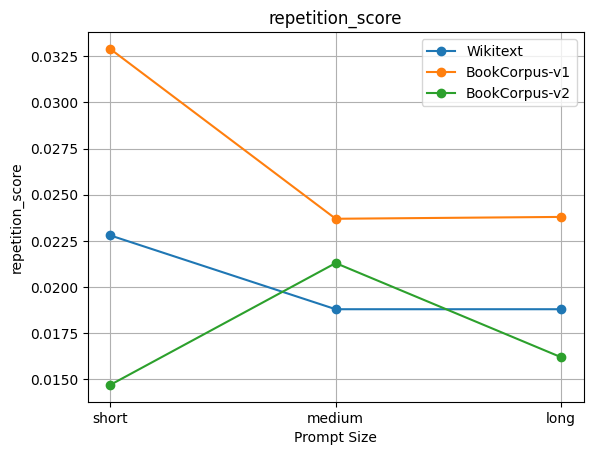

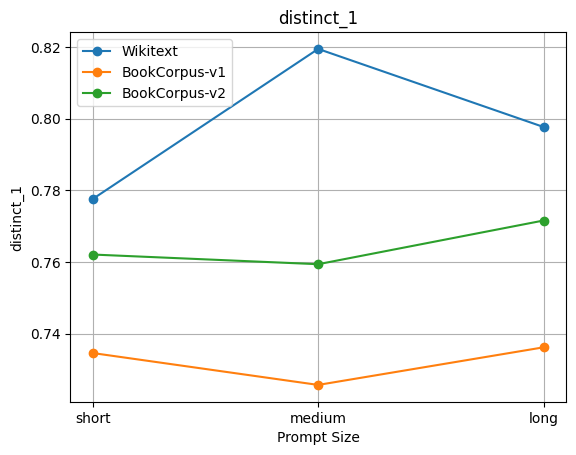

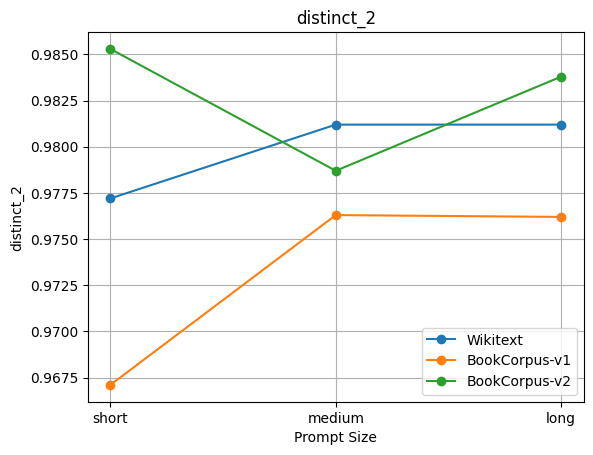

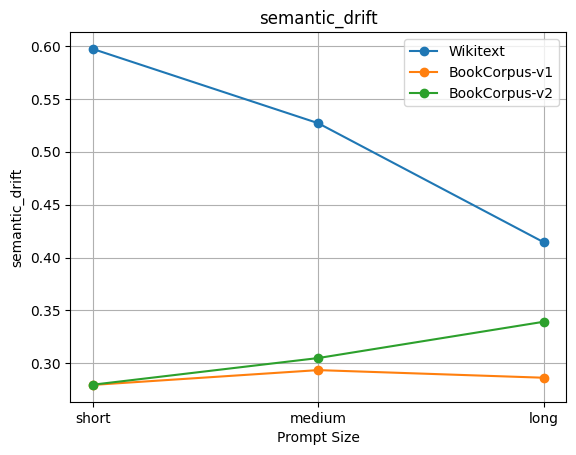

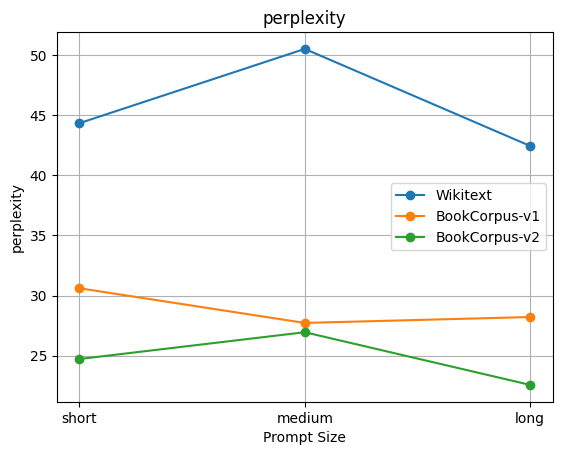

In [64]:
metrics = list(data["short"].keys())
prompt_sizes = ["short", "medium", "long"]

for metric in metrics:
    plt.figure()
    
    for i, model in enumerate(models):
        values = [data[size][metric][i] for size in prompt_sizes]
        plt.plot(prompt_sizes, values, marker='o', label=model)
    
    plt.title(metric)
    plt.xlabel("Prompt Size")
    plt.ylabel(metric)
    plt.legend()
    plt.grid()

    plt.show()

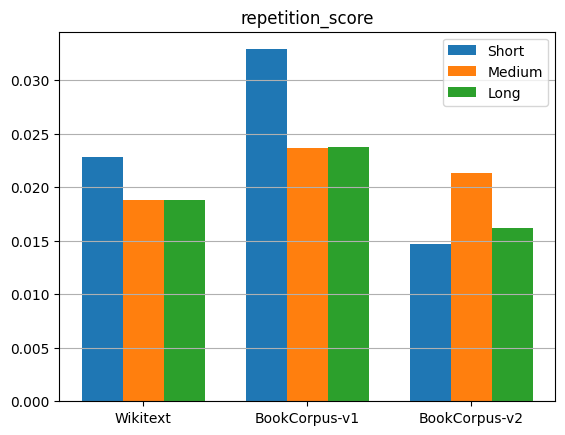

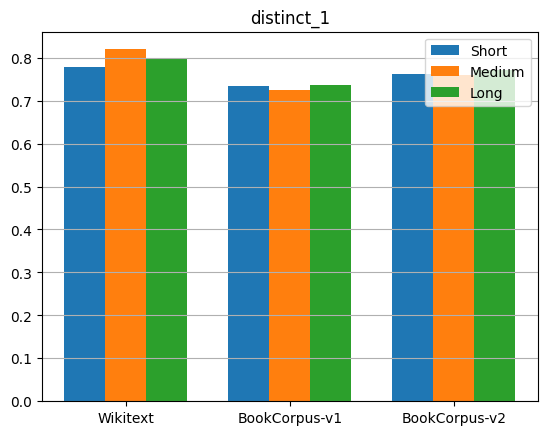

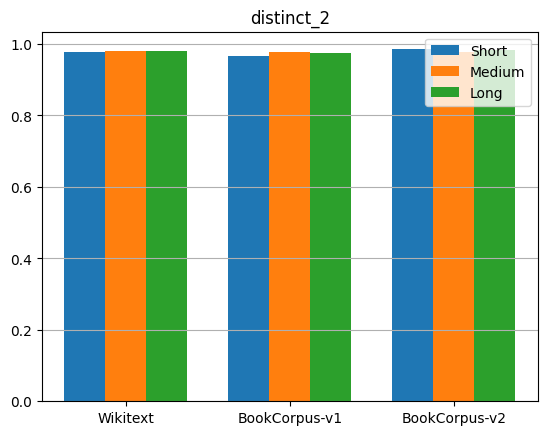

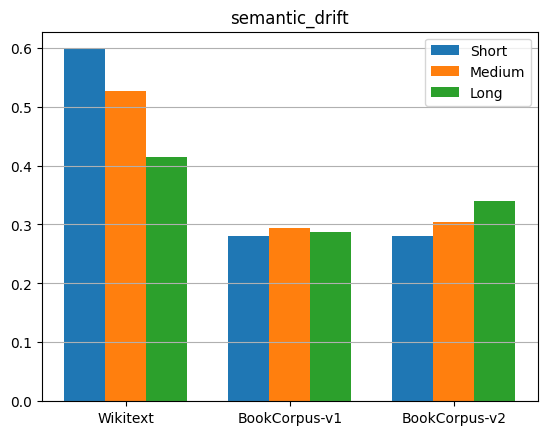

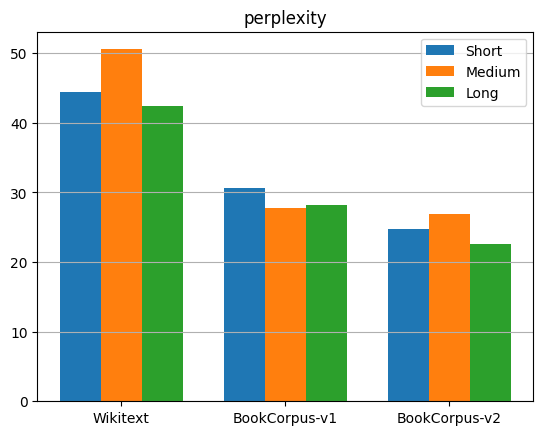

In [65]:
x = np.arange(len(models))
width = 0.25

for metric in metrics:
    plt.figure()

    short_vals = data["short"][metric]
    medium_vals = data["medium"][metric]
    long_vals = data["long"][metric]

    plt.bar(x - width, short_vals, width, label='Short')
    plt.bar(x, medium_vals, width, label='Medium')
    plt.bar(x + width, long_vals, width, label='Long')

    plt.xticks(x, models)
    plt.title(metric)
    plt.legend()
    plt.grid(axis='y')

    plt.show()

In [56]:
metric_keys = ["repetition_score", "distinct_1", "distinct_2", "semantic_drift", "perplexity"]

header = f"{'Model':<18}" + "".join(f"{k:<22}" for k in metric_keys)
print(header)
print("-" * len(header))

for model_name in MODELS:
    all_records = []
    for bracket_dict in all_results.values():
        all_records.extend(bracket_dict[model_name])
    avgs = {k: round(np.mean([r[k] for r in all_records]), 4) for k in metric_keys}
    print(f"{model_name:<18}" + "".join(f"{avgs[k]:<22}" for k in metric_keys))

Model             repetition_score      distinct_1            distinct_2            semantic_drift        perplexity            
--------------------------------------------------------------------------------------------------------------------------------
Wikitext          0.0201                0.7983                0.9799                0.5129                45.787                
BookCorpus-v1     0.0268                0.7322                0.9732                0.2865                28.842                
BookCorpus-v2     0.0174                0.7644                0.9826                0.308                 24.7327               


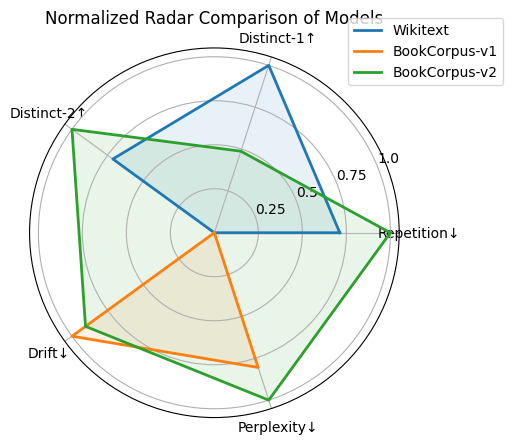

In [43]:
# Generate an improved radar chart (clean + mathematically normalized)

import numpy as np
import matplotlib.pyplot as plt

models = ["Wikitext", "BookCorpus-v1", "BookCorpus-v2"]

repetition = np.array([0.0201, 0.0268, 0.0174])
distinct1 = np.array([0.7983, 0.7322, 0.7644])
distinct2 = np.array([0.9799, 0.9732, 0.9826])
drift = np.array([0.5129, 0.2865, 0.308])
perplexity = np.array([45.787, 28.842, 24.7327])

# Normalize each metric
def normalize(x):
    return (x - x.min()) / (x.max() - x.min())

rep_n = 1 - normalize(repetition)   # invert (lower is better)
d1_n = normalize(distinct1)
d2_n = normalize(distinct2)
drift_n = 1 - normalize(drift)      # invert
ppl_n = 1 - normalize(perplexity)   # invert

data = np.vstack([rep_n, d1_n, d2_n, drift_n, ppl_n])

labels = ["Repetition↓", "Distinct-1↑", "Distinct-2↑", "Drift↓", "Perplexity↓"]
angles = np.linspace(0, 2*np.pi, len(labels), endpoint=False)
angles = np.concatenate([angles, [angles[0]]])

plt.figure()
ax = plt.subplot(111, polar=True)

for i, model in enumerate(models):
    values = np.concatenate([data[:, i], [data[0, i]]])
    ax.plot(angles, values, linewidth=2, label=model)
    ax.fill(angles, values, alpha=0.1)

ax.legend(loc="upper right", bbox_to_anchor=(1.3, 1.1))

ax.set_xticks(angles[:-1])
ax.set_xticklabels(labels)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.5", "0.75", "1.0"])
ax.set_title("Normalized Radar Comparison of Models")
plt.legend
plt.show()